In [11]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
import h5py
import glob
import glob
import os
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import find_peaks
import neurokit2 as nk

In [13]:
H5_DIRS = {
    "day1": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs", #update to your paths
    "day2": r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs",
}

In [3]:
def load_clean_resp_signal_ecu(h5_file, target_rate=100, fs=20000):
    """
    Loads, filters, downsamples respiration from ECU-style .h5.
    Preserves original preprocessing logic.
    
    Returns:
        rsp_cleaned : np.ndarray
        time_vector : np.ndarray
        fs_out      : float (target_rate)
        metadata    : dict
    """

    try:
        with h5py.File(h5_file, 'r') as f:

            # -----------------------------
            # Load respiration (ECU Ain1)
            # -----------------------------
            analog_keys = list(f['analog'].keys())
            resp_keys = [k for k in analog_keys if "Ain1" in k]
            if len(resp_keys) == 0:
                raise RuntimeError("No ECU Ain1 channel found")

            resp_key = resp_keys[0]
            resp = f['analog'][resp_key][()]['voltage'].astype(float)

            # -----------------------------
            # Metadata (keep for compatibility)
            # -----------------------------
            metadata = {
                "fs_original": fs,
                "source": "ECU_Ain1",
                "file": os.path.basename(h5_file)
            }

    except Exception as e:
        print(f" Error loading {os.path.basename(h5_file)}: {e}")
        return None, None, None, None

    # -----------------------------
    # PRE-CLEAN (CRITICAL)
    # -----------------------------
    # Remove NaNs / infs
    bad = ~np.isfinite(resp)
    if np.any(bad):
        resp[bad] = np.nanmedian(resp)

    # Remove DC offset
    resp = resp - np.median(resp)

    # Clip extreme artifacts (opto / motion)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # -----------------------------
    # Low-pass before downsampling
    # -----------------------------
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # -----------------------------
    # Downsample
    # -----------------------------
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # -----------------------------
    # Bandpass (NeuroKit)
    # -----------------------------
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # -----------------------------
    # Time vector
    # -----------------------------
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata

In [4]:
def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [5]:
import h5py

h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\1_1_RI1_f1_d_on_20260111_164638.h5"

with h5py.File(h5_file, "r") as f:
    print("DIO keys:", f["dio"].keys())



DIO keys: <KeysViewHDF5 ['1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1', '1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1']>


In [6]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [7]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [8]:
with h5py.File(h5_file, "r") as f:
    for k in f["dio"].keys():
        dset = f["dio"][k]
        print("\nDIO key:", k)
        print("Type:", type(dset))
        print("Dtype:", dset.dtype)
        print("Dtype names:", dset.dtype.names)
        print("Shape:", dset.shape)




DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Din1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (6547,)

DIO key: 1_1_RI1_f1_d_on_20260111_164638.dio_ECU_Dout1
Type: <class 'h5py._hl.dataset.Dataset'>
Dtype: [('time', '<u4'), ('state', 'u1')]
Dtype names: ('time', 'state')
Shape: (1,)


In [9]:
with h5py.File(h5_file, "r") as f:
    print("Time group keys:", f["time"].keys())



Time group keys: <KeysViewHDF5 ['1_1_RI1_f1_d_on_20260111_164638.timestamps']>


In [10]:
def extract_laser_ttl_times_ecu(h5_file, trodes_rate=20000):
    """
    Extract rising-edge laser TTL pulse times (seconds)
    from ECU_Din1 using Trodes clock ticks (20 kHz).
    """
    import h5py
    import numpy as np

    with h5py.File(h5_file, "r") as f:
        # Find ECU_Din1 (laser pulses)
        dio_keys = [k for k in f["dio"].keys() if "ECU_Din1" in k]
        if len(dio_keys) == 0:
            return np.array([])

        dio = f["dio"][dio_keys[0]][()]
        dio_ticks = dio["time"].astype(float)   # Trodes ticks
        dio_states = dio["state"].astype(int)   # 0 / 1

    # Rising edges (0 → 1)
    rising_edges = np.where(np.diff(dio_states) == 1)[0]

    # Convert ticks → seconds
    pulse_times_sec = dio_ticks[rising_edges] / trodes_rate

    return pulse_times_sec


In [11]:
with h5py.File(h5_file, "r") as f:
    time_key = list(f["time"].keys())[0]
    global_time = f["time"][time_key][()]

print(global_time.dtype.names)



('time', 'systime')


In [12]:
pulse_times = extract_laser_ttl_times_ecu(h5_file)

print("Total pulses:", len(pulse_times))
print("First pulse (s):", pulse_times[0])
print("Last pulse (s):", pulse_times[-1])

print("Baseline pulses:", np.sum(pulse_times < 60))
print("RI pulses:", np.sum((pulse_times >= 60) & (pulse_times <= 240)))


Total pulses: 3273
First pulse (s): 321.66025
Last pulse (s): 564.12595
Baseline pulses: 0
RI pulses: 0


In [13]:
def load_resp_simple(h5_file, target_rate=100, trodes_rate=20000):
    import h5py
    import numpy as np
    from scipy.signal import butter, filtfilt, resample_poly
    import neurokit2 as nk

    with h5py.File(h5_file, 'r') as f:
        resp_key = [k for k in f['analog'].keys() if "Ain1" in k][0]
        resp = f['analog'][resp_key][()]['voltage'].astype(float)

    # Time relative to recording start
    t = np.arange(len(resp)) / trodes_rate

    # Clean
    resp -= np.median(resp)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # Low-pass + downsample
    nyq = trodes_rate / 2
    b, a = butter(4, (target_rate / 2) / nyq, btype="low")
    resp_filt = filtfilt(b, a, resp)

    down = int(trodes_rate // target_rate)
    resp_ds = resample_poly(resp_filt, up=1, down=down)
    t_ds = t[::down]

    # Bandpass
    resp_clean = nk.signal_filter(
        resp_ds,
        lowcut=0.1,
        highcut=20,
        sampling_rate=target_rate,
        order=2
    )

    return resp_clean, t_ds


In [14]:
SOCIAL_START = 60
SOCIAL_END   = 240


In [15]:
rsp, t = load_resp_simple(h5_file)

social_rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=SOCIAL_START,
    sniff_end=SOCIAL_END,
    sampling_rate=100
)

print("Social respiration rate (Hz):", social_rate)


Social respiration rate (Hz): 9.152318103834027


In [16]:
import os

all_files = []

for day, folder in H5_DIRS.items():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files found:", len(all_files))


Total files found: 47


ValueError: num must be an integer with 1 <= num <= 24, not 25

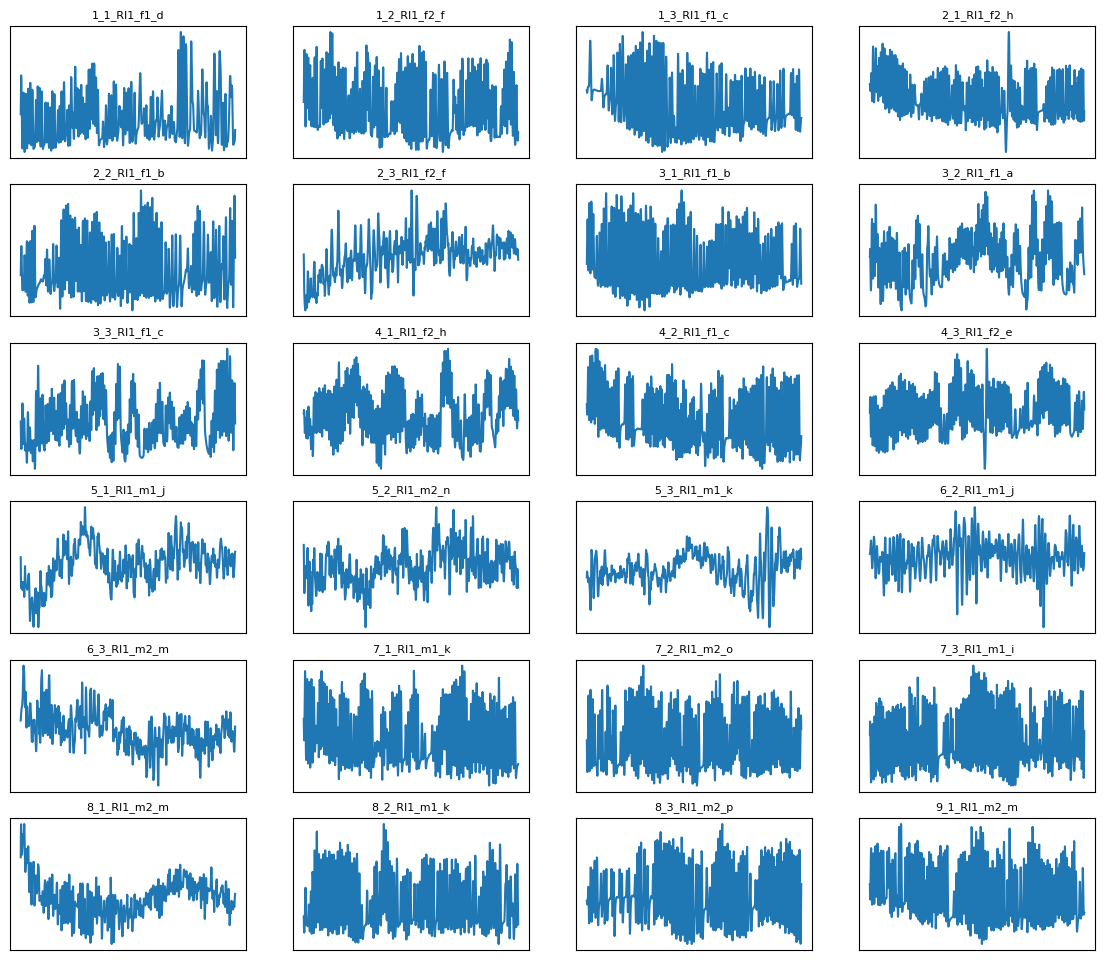

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

for i, h5_file in enumerate(all_files):
    rsp, t = load_resp_simple(h5_file)

    # Zoom to first 10 seconds (sampling rate = 100 Hz → 1000 samples)
    samples = 1000
    
    plt.subplot(6, 4, i+1)  # adjust grid size if needed
    plt.plot(t[:samples], rsp[:samples])
    plt.title(os.path.basename(h5_file)[:12], fontsize=8)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


In [18]:
on_files = [f for f in all_files if "_on_" in f]
off_files = [f for f in all_files if "_off_" in f]

print("ON files:", len(on_files))
print("OFF files:", len(off_files))


ON files: 24
OFF files: 23


In [19]:
import os

on_subjects = sorted([os.path.basename(f).split("_")[0] + "_" + os.path.basename(f).split("_")[1] 
                      for f in on_files])

off_subjects = sorted([os.path.basename(f).split("_")[0] + "_" + os.path.basename(f).split("_")[1] 
                       for f in off_files])

print("Missing OFF:", set(on_subjects) - set(off_subjects))
print("Missing ON:", set(off_subjects) - set(on_subjects))


Missing OFF: {'5_1'}
Missing ON: set()


Total files: 47


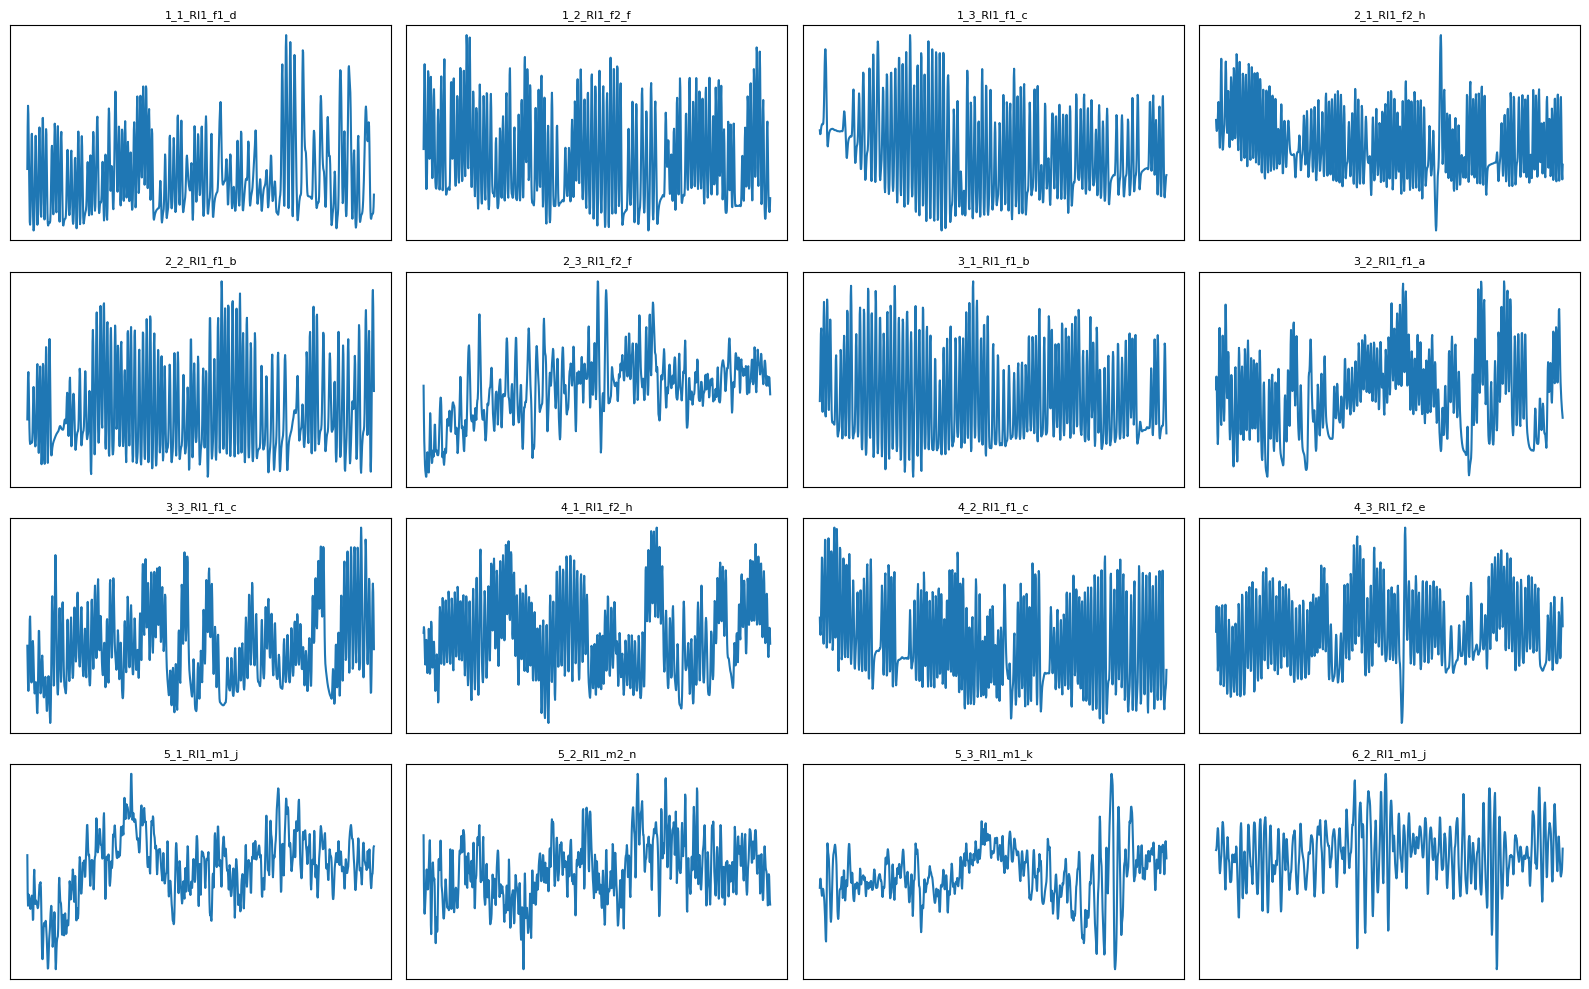

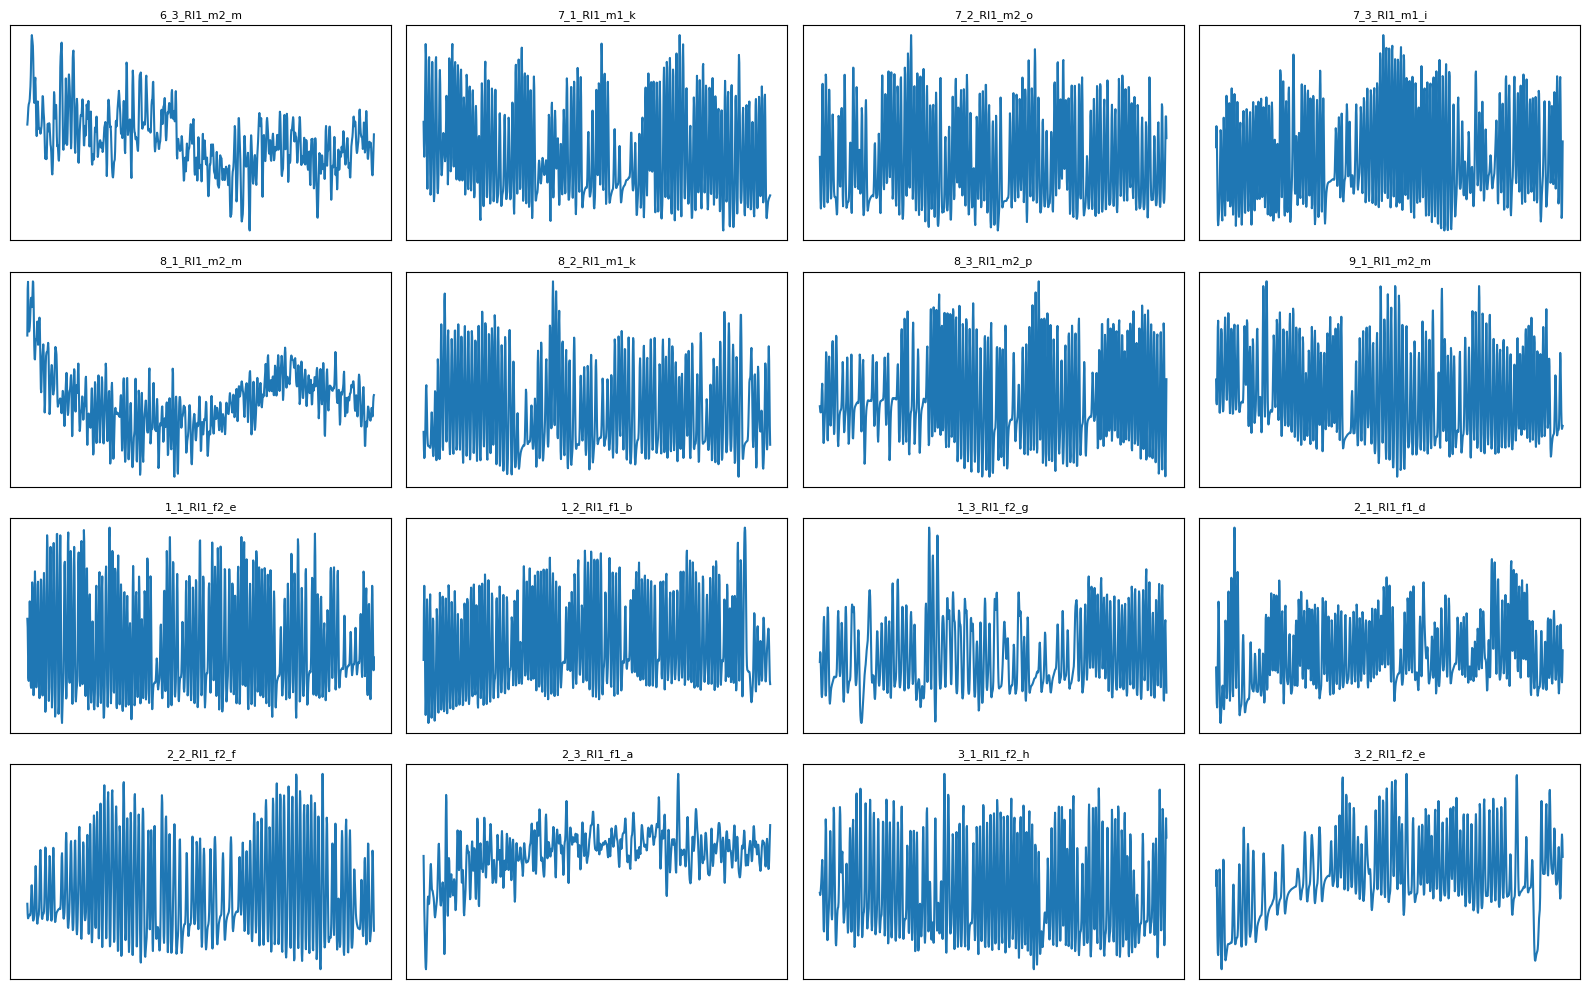

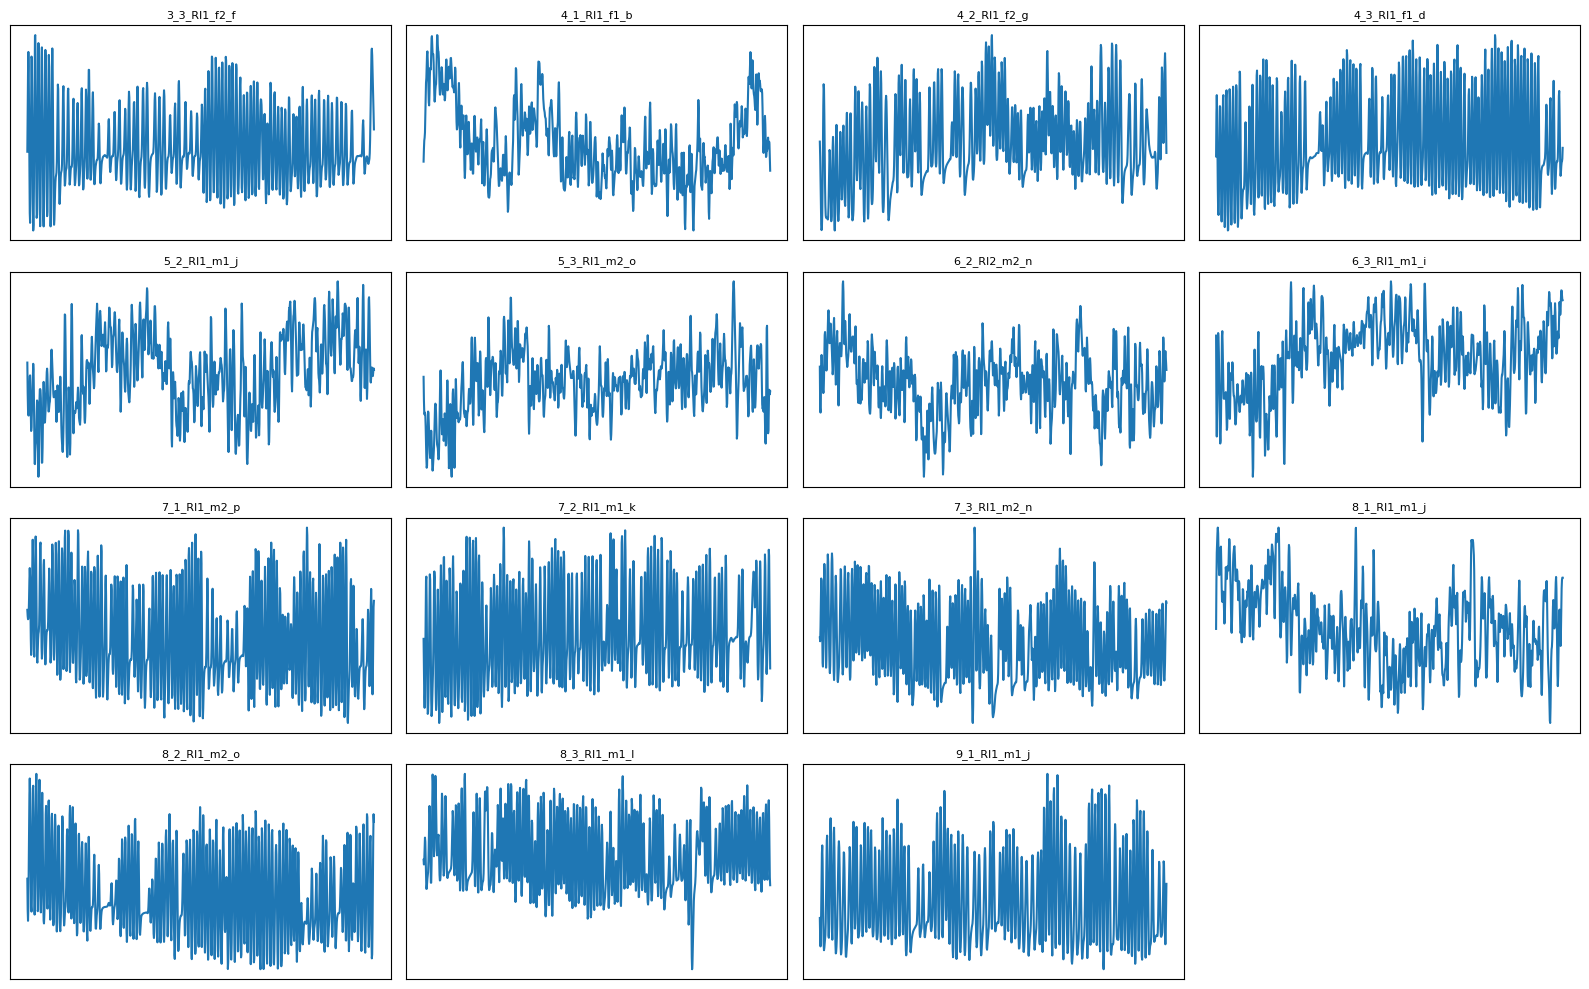

In [20]:
import os
import math
import matplotlib.pyplot as plt

# Combine both days
all_files = []
for folder in H5_DIRS.values():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files:", len(all_files))

batch_size = 16  # show 16 at a time
samples = 1000   # first ~10 seconds (100 Hz)

for start in range(0, len(all_files), batch_size):
    batch = all_files[start:start+batch_size]
    
    cols = 4
    rows = math.ceil(len(batch) / cols)
    
    plt.figure(figsize=(4*cols, 2.5*rows))
    
    for i, h5_file in enumerate(batch):
        rsp, t = load_resp_simple(h5_file)
        
        plt.subplot(rows, cols, i+1)
        plt.plot(t[:samples], rsp[:samples])
        plt.title(os.path.basename(h5_file)[:12], fontsize=8)
        plt.xticks([])
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()


In [21]:
import numpy as np
import pandas as pd

qc_metrics = []

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "std": np.std(rsp),
        "range": np.max(rsp) - np.min(rsp),
        "mean": np.mean(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

qc_df.sort_values("std")


,file,std,range,mean
33,4_1_RI1_f1_b_off_20260110_165525.h5,1.110086,9.453438,0.013350
13,5_2_RI1_m2_n_off_20260110_135659.h5,1.207971,10.065365,-0.009803
43,8_1_RI1_m1_j_off_20260111_135412.h5,1.681473,18.663136,0.014856
14,5_3_RI1_m1_k_off_20260109_183135.h5,1.806313,22.108640,-0.005582
16,6_3_RI1_m2_m_off_20260109_174951.h5,2.072387,37.142162,0.011197
29,2_3_RI1_f1_a_off_20260111_141011.h5,2.377846,35.699863,-0.029523
12,5_1_RI1_m1_j_on_20260111_150428.h5,4.243318,26.993278,-0.014202
36,5_2_RI1_m1_j_on_20260111_133010.h5,4.615461,28.965659,-0.008892
38,6_2_RI2_m2_n_on_20260110_190944.h5,4.636336,26.550109,0.002245
37,5_3_RI1_m2_o_on_20260110_160743.h5,4.716260,29.085397,-0.011024


In [22]:
qc_df

,file,std,range,mean
0,1_1_RI1_f1_d_on_20260111_164638.h5,398.290569,4448.892152,-0.529422
1,1_2_RI1_f2_f_off_20260109_165330.h5,326.210282,2716.663758,0.307675
2,1_3_RI1_f1_c_off_20260110_130254.h5,277.362850,2673.364308,1.232536
3,2_1_RI1_f2_h_on_20260110_145355.h5,250.412452,2576.901473,1.841883
4,2_2_RI1_f1_b_off_20260109_150435.h5,428.592140,3936.356729,-0.198125
5,2_3_RI1_f2_f_on_20260110_132734.h5,4.852298,30.099076,-0.030480
6,3_1_RI1_f1_b_on_20260111_154618.h5,319.129783,3931.946237,0.198980
7,3_2_RI1_f1_a_off_20260114_161949.h5,191.341356,1696.643227,-0.973481
8,3_3_RI1_f1_c_on_20260111_162426.h5,186.857874,1630.344924,-0.089199
9,4_1_RI1_f2_h_on_20260111_161337.h5,184.891273,1788.525401,0.124046


Files with STD < 20:
5      2_3_RI1_f2_f_on_20260110_132734.h5
12     5_1_RI1_m1_j_on_20260111_150428.h5
13    5_2_RI1_m2_n_off_20260110_135659.h5
14    5_3_RI1_m1_k_off_20260109_183135.h5
15    6_2_RI1_m1_j_off_20260109_191750.h5
16    6_3_RI1_m2_m_off_20260109_174951.h5
20     8_1_RI1_m2_m_on_20260110_144121.h5
29    2_3_RI1_f1_a_off_20260111_141011.h5
33    4_1_RI1_f1_b_off_20260110_165525.h5
36     5_2_RI1_m1_j_on_20260111_133010.h5
37     5_3_RI1_m2_o_on_20260110_160743.h5
38     6_2_RI2_m2_n_on_20260110_190944.h5
39     6_3_RI1_m1_i_on_20260110_181825.h5
43    8_1_RI1_m1_j_off_20260111_135412.h5
Name: file, dtype: object


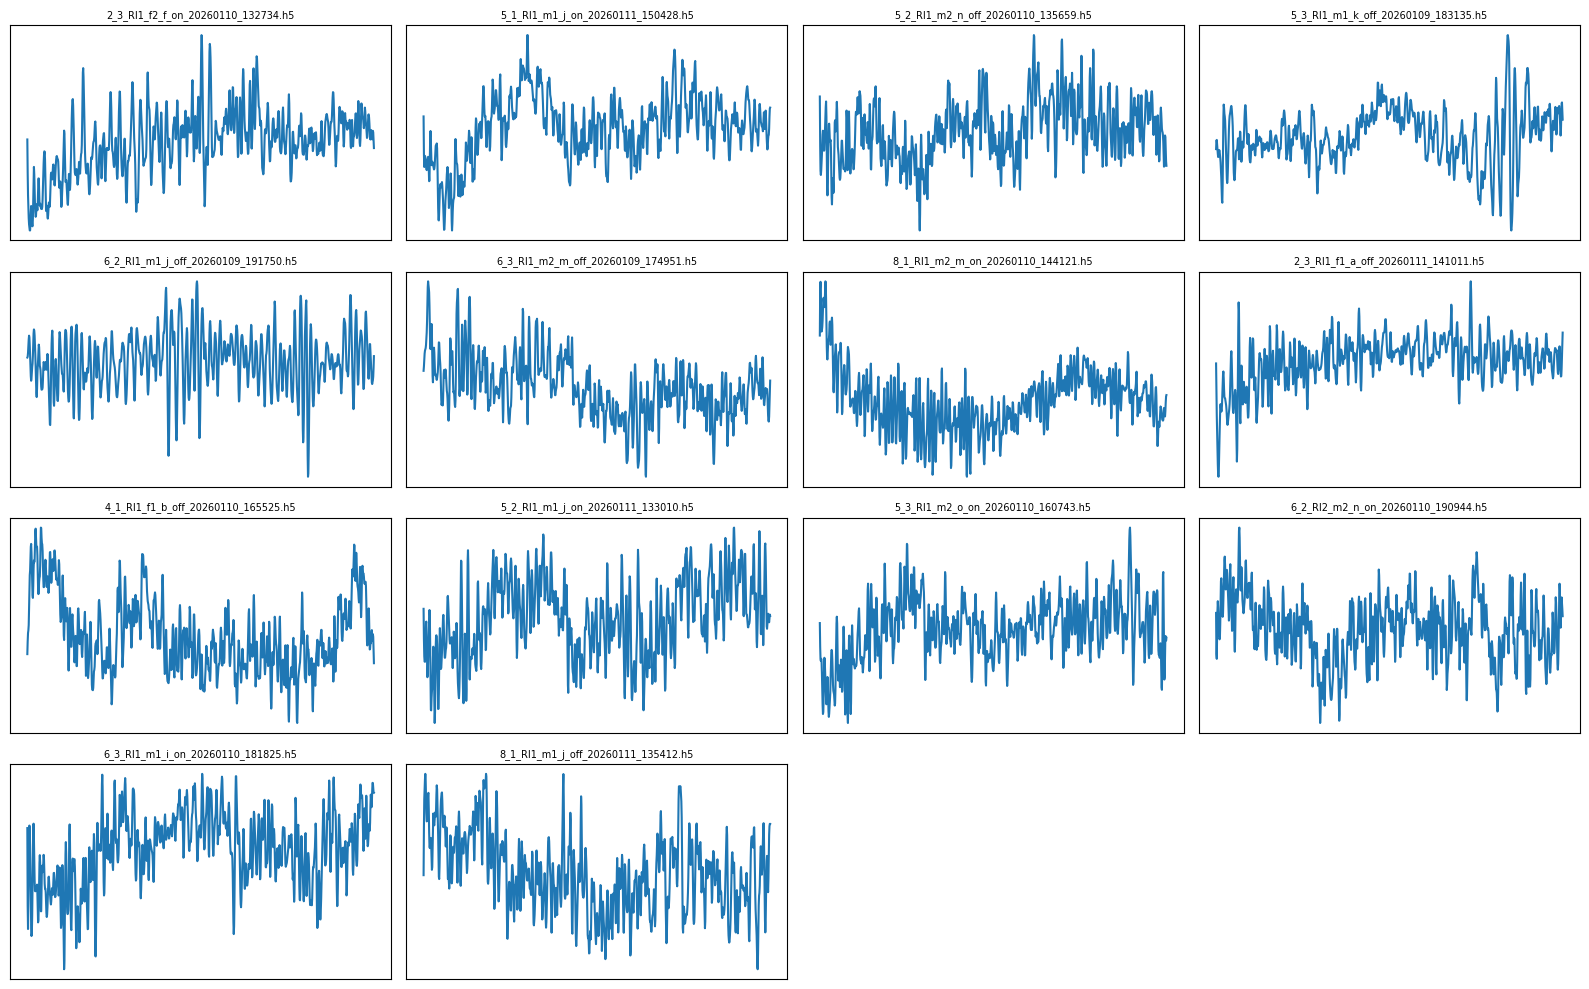

In [23]:
low_std_files = qc_df[qc_df["std"] < 20]["file"]

print("Files with STD < 20:")
print(low_std_files)

import math
import matplotlib.pyplot as plt

low_paths = [f for f in all_files if os.path.basename(f) in low_std_files.values]

cols = 4
rows = math.ceil(len(low_paths) / cols)

plt.figure(figsize=(4*cols, 2.5*rows))

for i, h5_file in enumerate(low_paths):
    rsp, t = load_resp_simple(h5_file)
    plt.subplot(rows, cols, i+1)
    plt.plot(t[:1000], rsp[:1000])
    plt.title(os.path.basename(h5_file), fontsize=7)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


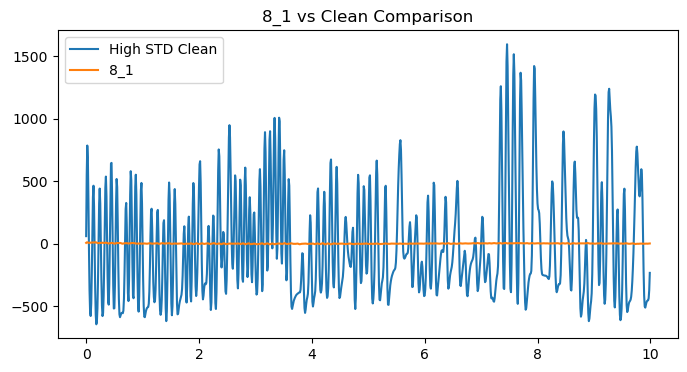

In [30]:
file_8_1 = [f for f in all_files if "8_1" in f][0]
clean_example = non_cage5_files[0]

rsp_8, t_8 = load_resp_simple(file_8_1)
rsp_clean, t_clean = load_resp_simple(clean_example)

plt.figure(figsize=(8,4))
plt.plot(t_clean[:1000], rsp_clean[:1000], label="High STD Clean")
plt.plot(t_8[:1000], rsp_8[:1000], label="8_1")
plt.legend()
plt.title("8_1 vs Clean Comparison")
plt.show()


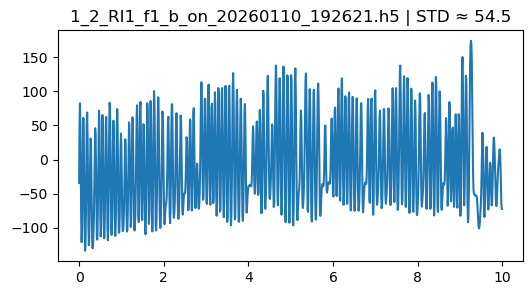

In [25]:
mid_std_file = qc_df[(qc_df["std"] > 40) & (qc_df["std"] < 80)]["file"].iloc[0]

mid_path = [f for f in all_files if os.path.basename(f) == mid_std_file][0]

rsp_mid, t_mid = load_resp_simple(mid_path)

plt.figure(figsize=(6,3))
plt.plot(t_mid[:1000], rsp_mid[:1000])
plt.title(f"{mid_std_file} | STD ≈ {qc_df[qc_df['file']==mid_std_file]['std'].values[0]:.1f}")
plt.show()


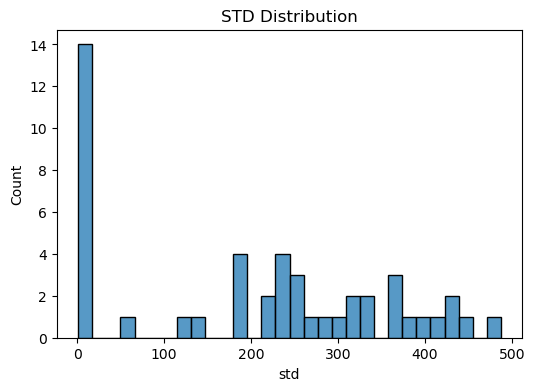

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(qc_df["std"], bins=30)
plt.title("STD Distribution")
plt.show()


In [27]:
cage5_files = [f for f in all_files if os.path.basename(f).startswith("5_")]
non_cage5_files = [f for f in all_files if not os.path.basename(f).startswith("5_")]

print("Cage 5 files:", len(cage5_files))
print("Non-cage 5 files:", len(non_cage5_files))


Cage 5 files: 5
Non-cage 5 files: 42


In [28]:
import pandas as pd
import numpy as np

qc_metrics = []

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    
    qc_metrics.append({
        "file": os.path.basename(h5_file),
        "cage5": os.path.basename(h5_file).startswith("5_"),
        "std": np.std(rsp)
    })

qc_df = pd.DataFrame(qc_metrics)

print("Mean STD (cage5):", qc_df[qc_df["cage5"]]["std"].mean())
print("Mean STD (non-cage5):", qc_df[~qc_df["cage5"]]["std"].mean())


Mean STD (cage5): 3.3178645079436295
Mean STD (non-cage5): 225.72306475578816


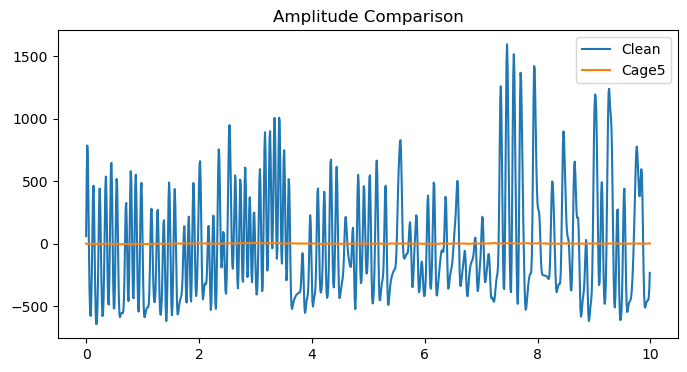

In [34]:
clean_example = non_cage5_files[0]
cage5_example = cage5_files[0]

rsp_clean, t_clean = load_resp_simple(clean_example)
rsp_c5, t_c5 = load_resp_simple(cage5_example)

plt.figure(figsize=(8,4))
plt.plot(t_clean[:1000], rsp_clean[:1000], label="Clean")
plt.plot(t_c5[:1000], rsp_c5[:1000], label="Cage5")
plt.legend()
plt.title("Amplitude Comparison")
plt.show()


In [33]:
# Identify bad files
bad_files = qc_df[qc_df["std"] < 20]["file"]

# Extract subject IDs
bad_subjects = set(["_".join(f.split("_")[:2]) for f in bad_files])

print("Subjects flagged for exclusion:")
print(bad_subjects)
print("Total subjects removed:", len(bad_subjects))

# Filter respiration dataframe
df_resp_clean = df_clean[~df_clean["Subject"].isin(bad_subjects)].copy()

print("Remaining respiration subjects:", df_resp_clean["Subject"].nunique())


Subjects flagged for exclusion:
{'5_1', '6_3', '4_1', '6_2', '5_2', '8_1', '5_3', '2_3'}
Total subjects removed: 8


NameError: name 'df_clean' is not defined

In [31]:
df_resp_clean.groupby(["Sex", "Virus"])["Subject"].nunique()


NameError: name 'df_resp_clean' is not defined

In [32]:
df_f = df_resp_clean[df_resp_clean["Sex"] == "Female"]

model_f = smf.mixedlm(
    "SocialRespRate ~ Virus * Laser",
    data=df_f,
    groups=df_f["Subject"]
)

result_f = model_f.fit()
print(result_f.summary())


NameError: name 'df_resp_clean' is not defined

In [64]:
import statsmodels.formula.api as smf

# Subset males only
df_m = df_resp_clean[df_resp_clean["Sex"] == "Male"]

model_m = smf.mixedlm(
    "SocialRespRate ~ Virus * Laser",
    data=df_m,
    groups=df_m["Subject"]
)

result_m = model_m.fit()
print(result_m.summary())


              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   SocialRespRate
No. Observations:   12        Method:               REML          
No. Groups:         6         Scale:                0.2295        
Min. group size:    2         Log-Likelihood:       -7.9984       
Max. group size:    2         Converged:            Yes           
Mean group size:    2.0                                           
------------------------------------------------------------------
                         Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                8.737    0.254 34.347 0.000  8.238  9.235
Virus[T.GFP]             0.588    0.441  1.334 0.182 -0.276  1.451
Laser[T.ON]              0.018    0.339  0.054 0.957 -0.645  0.682
Virus[T.GFP]:Laser[T.ON] 0.049    0.587  0.083 0.934 -1.101  1.198
Group Var                0.029    0.301                           



In [66]:
from scipy.stats import ttest_rel

df_m_chr = df_resp_clean[
    (df_resp_clean["Sex"] == "Male") &
    (df_resp_clean["Virus"] == "ChR")
]

pivot_m_chr = df_m_chr.pivot(index="Subject", columns="Laser", values="SocialRespRate")

t_stat, p_val = ttest_rel(pivot_m_chr["ON"], pivot_m_chr["OFF"])

print("Male ChR paired t-test")
print("t =", t_stat)
print("p =", p_val)


Male ChR paired t-test
t = 0.048767131187604056
p = 0.9641699611120027


In [67]:
model_collapsed = smf.mixedlm(
    "SocialRespRate ~ Virus * Laser",
    data=df_resp_clean,
    groups=df_resp_clean["Subject"]
)

result_collapsed = model_collapsed.fit()
print(result_collapsed.summary())


               Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   SocialRespRate
No. Observations:    32        Method:               REML          
No. Groups:          16        Scale:                0.1930        
Min. group size:     2         Log-Likelihood:       -28.4895      
Max. group size:     2         Converged:            Yes           
Mean group size:     2.0                                           
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 8.722    0.197 44.381 0.000  8.337  9.107
Virus[T.GFP]              0.194    0.321  0.604 0.546 -0.435  0.823
Laser[T.ON]               0.092    0.196  0.470 0.639 -0.293  0.477
Virus[T.GFP]:Laser[T.ON] -0.229    0.321 -0.715 0.475 -0.858  0.399
Group Var                 0.193    0.353                       

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="cage5", y="std", data=qc_df)
plt.xticks([0,1], ["Non-Cage5", "Cage5"])
plt.title("Respiration Signal STD Comparison")
plt.show()


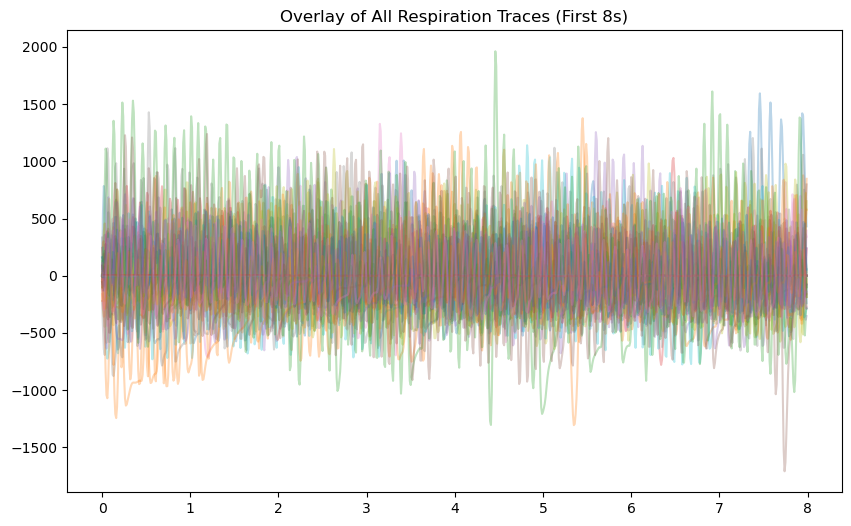

In [46]:
plt.figure(figsize=(10,6))

for h5_file in all_files:
    rsp, t = load_resp_simple(h5_file)
    plt.plot(t[:800], rsp[:800], alpha=0.3)

plt.title("Overlay of All Respiration Traces (First 8s)")
plt.show()


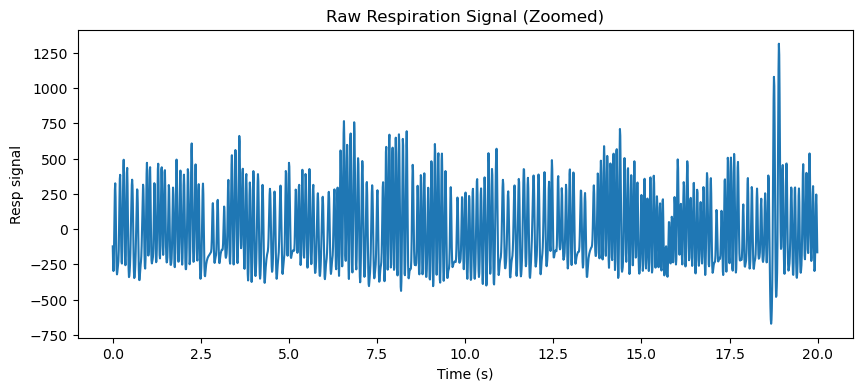

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(t[:2000], rsp[:2000])  # first ~20 seconds if sampling_rate=100
plt.xlabel("Time (s)")
plt.ylabel("Resp signal")
plt.title("Raw Respiration Signal (Zoomed)")
plt.show()


In [35]:
rows = []

for day, h5_dir in H5_DIRS.items():
    h5_files = glob.glob(os.path.join(h5_dir, "*.h5"))

    for h5_file in h5_files:
        rsp, t = load_resp_simple(h5_file)

        social_rate = get_sniff_respiratory_rate(
            signal=rsp,
            time=t,
            sniff_start=60,
            sniff_end=240,
            sampling_rate=100
        )

        rows.append({
            "File": os.path.basename(h5_file),
            "SocialRespRate": social_rate,
        })

df = pd.DataFrame(rows)


In [38]:
df["Laser"] = df["File"].str.contains("_on_").map(
    {True: "ON", False: "OFF"}
)

# Extract cage number (first number before "_")
df["Cage"] = df["File"].str.extract(r"^(\d+)").astype(int)

# Assign virus by cage parity
df["Virus"] = df["Cage"].apply(
    lambda x: "ChR" if x % 2 == 1 else "GFP"
)


df["Subject"] = df["File"].str.extract(r"(\d_\d)")


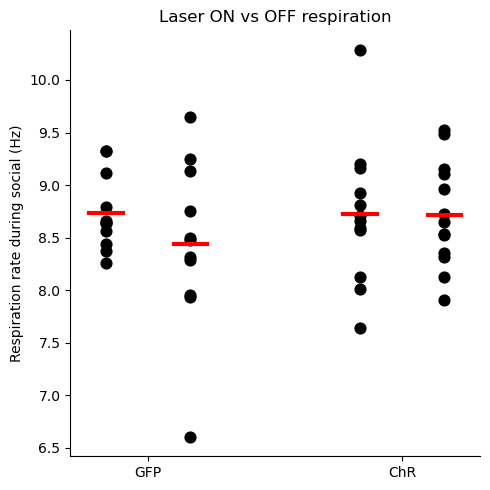

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

for i, virus in enumerate(["GFP", "ChR"]):
    sub = df[df["Virus"] == virus]

    for j, laser in enumerate(["OFF", "ON"]):
        vals = sub[sub["Laser"] == laser]["SocialRespRate"]

        x = i*3 + j
        ax.scatter(
            np.ones(len(vals))*x,
            vals,
            color="black",
            s=60
        )
        ax.plot(
            [x-0.2, x+0.2],
            [vals.mean(), vals.mean()],
            lw=3,
            color="red"
        )

ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


replot without flat recs

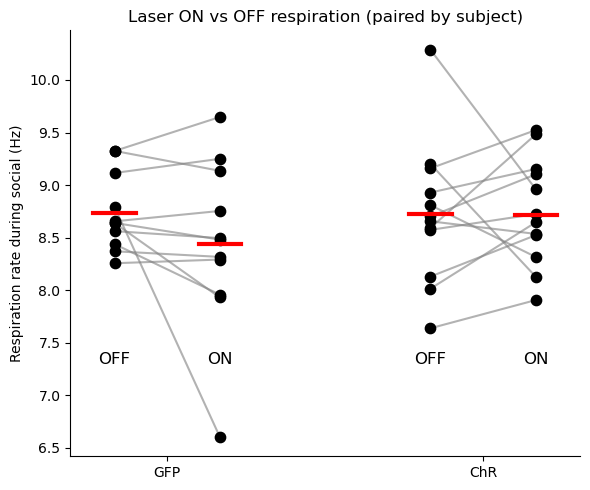

In [40]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

# x positions
xpos = {
    ("GFP", "OFF"): 0,
    ("GFP", "ON"):  1,
    ("ChR", "OFF"): 3,
    ("ChR", "ON"):  4,
}

for virus in ["GFP", "ChR"]:
    df_v = df[df["Virus"] == virus]

    for subject in df_v["Subject"].unique():
        sub_df = df_v[df_v["Subject"] == subject]

        # ensure we have both ON and OFF
        if set(sub_df["Laser"]) != {"ON", "OFF"}:
            continue

        off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
        on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

        x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
        y = [off_val, on_val]

        ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
        ax.scatter(x, y, color="black", s=55, zorder=2)

# Mean bars
for (virus, laser), x in xpos.items():
    vals = df[(df["Virus"] == virus) & (df["Laser"] == laser)]["SocialRespRate"]
    ax.plot(
        [x - 0.2, x + 0.2],
        [vals.mean(), vals.mean()],
        color="red",
        lw=3,
        zorder=3
    )

# Formatting
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration (paired by subject)")

# ON/OFF labels
ax.text(0, 7.3, "OFF", ha="center", fontsize=12)
ax.text(1, 7.3, "ON",  ha="center", fontsize=12)
ax.text(3, 7.3, "OFF", ha="center", fontsize=12)
ax.text(4, 7.3, "ON",  ha="center", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Original N subjects: 24
After exclusion N subjects: 16

Subjects remaining:
['1_1', '1_2', '1_3', '2_1', '2_2', '3_1', '3_2', '3_3', '4_2', '4_3', '7_1', '7_2', '7_3', '8_2', '8_3', '9_1']

Laser counts per subject (should all be 2):
Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
3_1    2
3_2    2
3_3    2
4_2    2
4_3    2
7_1    2
7_2    2
7_3    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64



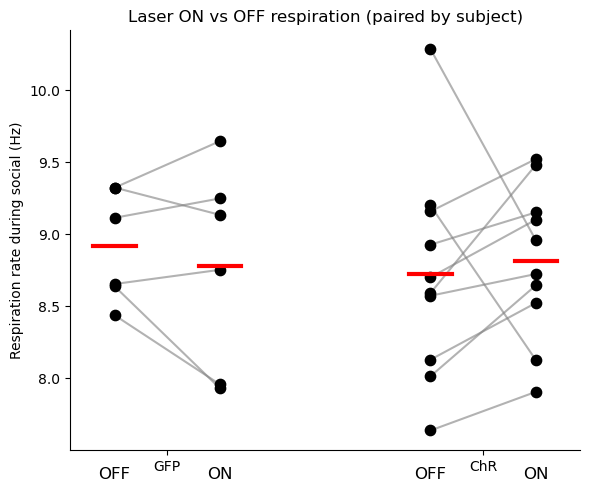

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1️⃣ EXCLUDE BAD SUBJECTS
# =====================================================

exclude_subjects = [
    "5_1", "5_2", "5_3",
    "2_3",
    "6_2", "6_3",
    "4_1",
    "8_1"
]

df_clean = df[~df["Subject"].isin(exclude_subjects)].copy()

# =====================================================
# 2️⃣ SANITY CHECKS
# =====================================================

print("Original N subjects:", df["Subject"].nunique())
print("After exclusion N subjects:", df_clean["Subject"].nunique())
print()

print("Subjects remaining:")
print(sorted(df_clean["Subject"].unique()))
print()

print("Laser counts per subject (should all be 2):")
print(df_clean.groupby("Subject")["Laser"].nunique())
print()

# =====================================================
# 3️⃣ PLOT PAIRED RESPIRATION
# =====================================================

fig, ax = plt.subplots(figsize=(6, 5))

# x positions
xpos = {
    ("GFP", "OFF"): 0,
    ("GFP", "ON"):  1,
    ("ChR", "OFF"): 3,
    ("ChR", "ON"):  4,
}

for virus in ["GFP", "ChR"]:
    df_v = df_clean[df_clean["Virus"] == virus]

    for subject in df_v["Subject"].unique():
        sub_df = df_v[df_v["Subject"] == subject]

        if set(sub_df["Laser"]) != {"ON", "OFF"}:
            continue

        off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
        on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

        x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
        y = [off_val, on_val]

        ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
        ax.scatter(x, y, color="black", s=55, zorder=2)

# Mean bars
for (virus, laser), x in xpos.items():
    vals = df_clean[
        (df_clean["Virus"] == virus) &
        (df_clean["Laser"] == laser)
    ]["SocialRespRate"]

    ax.plot(
        [x - 0.2, x + 0.2],
        [vals.mean(), vals.mean()],
        color="red",
        lw=3,
        zorder=3
    )

# Formatting
ax.set_xticks([0.5, 3.5])
ax.set_xticklabels(["GFP", "ChR"])
ax.set_ylabel("Respiration rate during social (Hz)")
ax.set_title("Laser ON vs OFF respiration (paired by subject)")

ax.text(0, 7.3, "OFF", ha="center", fontsize=12)
ax.text(1, 7.3, "ON",  ha="center", fontsize=12)
ax.text(3, 7.3, "OFF", ha="center", fontsize=12)
ax.text(4, 7.3, "ON",  ha="center", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [51]:
import pingouin as pg

# Make sure df_clean has only paired subjects
df_stats = df_clean.copy()

# Run mixed ANOVA
aov = pg.mixed_anova(
    data=df_stats,
    dv="SocialRespRate",
    within="Laser",
    between="Virus",
    subject="Subject"
)

print(aov)


        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0        Virus  0.047049    1   14  0.047049  0.081191  0.779862  0.005766   
1        Laser  0.000310    1   14  0.000310  0.001608  0.968582  0.000115   
2  Interaction  0.098684    1   14  0.098684  0.511351  0.486310  0.035238   

   eps  
0  NaN  
1  1.0  
2  NaN  


Sex     Virus
Female  ChR      6
        GFP      4
Male    ChR      4
        GFP      2
Name: Subject, dtype: int64


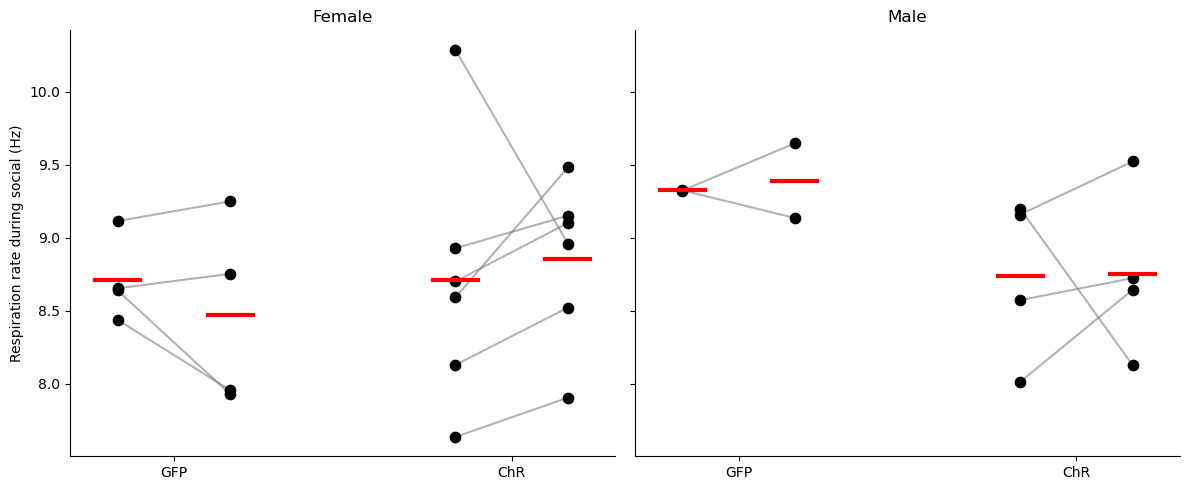

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1️⃣ EXCLUDE BAD SUBJECTS
# =====================================================

exclude_subjects = [
    "5_1", "5_2", "5_3",
    "2_3",
    "6_2", "6_3",
    "4_1",
    "8_1"
]

df_clean = df[~df["Subject"].isin(exclude_subjects)].copy()

# =====================================================
# 2️⃣ ADD SEX COLUMN (based on cage number)
# =====================================================

df_clean["Cage"] = df_clean["Subject"].str.split("_").str[0].astype(int)

df_clean["Sex"] = np.where(
    df_clean["Cage"].isin([1, 2, 3, 4]),
    "Female",
    "Male"
)

# =====================================================
# 3️⃣ SANITY CHECK
# =====================================================

print(df_clean.groupby(["Sex", "Virus"])["Subject"].nunique())

# =====================================================
# 4️⃣ PLOT SPLIT BY SEX
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sexes = ["Female", "Male"]

for ax, sex in zip(axes, sexes):

    df_sex = df_clean[df_clean["Sex"] == sex]

    xpos = {
        ("GFP", "OFF"): 0,
        ("GFP", "ON"):  1,
        ("ChR", "OFF"): 3,
        ("ChR", "ON"):  4,
    }

    for virus in ["GFP", "ChR"]:
        df_v = df_sex[df_sex["Virus"] == virus]

        for subject in df_v["Subject"].unique():
            sub_df = df_v[df_v["Subject"] == subject]

            if set(sub_df["Laser"]) != {"ON", "OFF"}:
                continue

            off_val = sub_df[sub_df["Laser"] == "OFF"]["SocialRespRate"].values[0]
            on_val  = sub_df[sub_df["Laser"] == "ON"]["SocialRespRate"].values[0]

            x = [xpos[(virus, "OFF")], xpos[(virus, "ON")]]
            y = [off_val, on_val]

            ax.plot(x, y, color="gray", alpha=0.6, zorder=1)
            ax.scatter(x, y, color="black", s=55, zorder=2)

    # Mean bars
    for (virus, laser), x in xpos.items():
        vals = df_sex[
            (df_sex["Virus"] == virus) &
            (df_sex["Laser"] == laser)
        ]["SocialRespRate"]

        if len(vals) == 0:
            continue

        ax.plot(
            [x - 0.2, x + 0.2],
            [vals.mean(), vals.mean()],
            color="red",
            lw=3,
            zorder=3
        )

    ax.set_xticks([0.5, 3.5])
    ax.set_xticklabels(["GFP", "ChR"])
    ax.set_title(sex)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Respiration rate during social (Hz)")

plt.tight_layout()
plt.show()


In [45]:
# =====================================================
# BASIC OVERVIEW
# =====================================================

print("Shape of dataframe:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 10 rows:")
display(df.head(10))

# =====================================================
# SUBJECT SUMMARY
# =====================================================

print("\nUnique Subjects:")
print(sorted(df["Subject"].unique()))

print("\nNumber of subjects:", df["Subject"].nunique())

# =====================================================
# CHECK VIRUS GROUPS
# =====================================================

print("\nVirus counts:")
print(df["Virus"].value_counts())

# =====================================================
# CHECK LASER CONDITIONS
# =====================================================

print("\nLaser counts:")
print(df["Laser"].value_counts())

print("\nLaser per subject (should be 2 for paired design):")
print(df.groupby("Subject")["Laser"].nunique())

# =====================================================
# LOOK AT RESPIRATION VALUES
# =====================================================

print("\nRespiration summary stats:")
display(
    df.groupby(["Virus", "Laser"])["SocialRespRate"]
      .describe()
)

# =====================================================
# CHECK FOR DUPLICATES
# =====================================================

print("\nDuplicate rows (Virus, Subject, Laser):")
print(df.duplicated(subset=["Virus", "Subject", "Laser"]).sum())

# =====================================================
# CHECK ON vs OFF DIFFERENCE PER SUBJECT
# =====================================================

pivot = (
    df.pivot_table(
        index=["Virus", "Subject"],
        columns="Laser",
        values="SocialRespRate"
    )
)

pivot["ON_minus_OFF"] = pivot["ON"] - pivot["OFF"]

print("\nON - OFF differences per subject:")
display(pivot)


Shape of dataframe: (47, 6)

Columns:
Index(['File', 'SocialRespRate', 'Laser', 'Cage', 'Virus', 'Subject'], dtype='object')

First 10 rows:


,File,SocialRespRate,Laser,Cage,Virus,Subject
0,1_1_RI1_f1_d_on_20260111_164638.h5,9.152318,ON,1,ChR,1_1
1,1_2_RI1_f2_f_off_20260109_165330.h5,10.288113,OFF,1,ChR,1_2
2,1_3_RI1_f1_c_off_20260110_130254.h5,8.591796,OFF,1,ChR,1_3
3,2_1_RI1_f2_h_on_20260110_145355.h5,9.249470,ON,2,GFP,2_1
4,2_2_RI1_f1_b_off_20260109_150435.h5,8.654789,OFF,2,GFP,2_2
5,2_3_RI1_f2_f_on_20260110_132734.h5,8.291091,ON,2,GFP,2_3
6,3_1_RI1_f1_b_on_20260111_154618.h5,9.101620,ON,3,ChR,3_1
7,3_2_RI1_f1_a_off_20260114_161949.h5,8.129087,OFF,3,ChR,3_2
8,3_3_RI1_f1_c_on_20260111_162426.h5,7.905516,ON,3,ChR,3_3
9,4_1_RI1_f2_h_on_20260111_161337.h5,6.603175,ON,4,GFP,4_1



Unique Subjects:
['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '3_1', '3_2', '3_3', '4_1', '4_2', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1']

Number of subjects: 24

Virus counts:
Virus
ChR    25
GFP    22
Name: count, dtype: int64

Laser counts:
Laser
ON     24
OFF    23
Name: count, dtype: int64

Laser per subject (should be 2 for paired design):
Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    1
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64

Respiration summary stats:


count      mean       std       min       25%       50%  \
Virus Laser                                                            
ChR   OFF     12.0  8.723852  0.674003  7.637106  8.462293  8.678216   
      ON      13.0  8.719298  0.500484  7.905516  8.354753  8.645307   
GFP   OFF     11.0  8.737897  0.367148  8.255986  8.500135  8.639853   
      ON      11.0  8.441859  0.812632  6.603175  8.124344  8.480627   

                  75%        max  
Virus Laser                       
ChR   OFF    8.986038  10.288113  
      ON     9.101620   9.523018  
GFP   OFF    8.953665   9.325129  
      ON     8.944623   9.647353


Duplicate rows (Virus, Subject, Laser):
0

ON - OFF differences per subject:


Laser                OFF        ON  ON_minus_OFF
Virus Subject                                   
ChR   1_1       8.928348  9.152318      0.223970
      1_2      10.288113  8.960292     -1.327822
      1_3       8.591796  9.482227      0.890430
      3_1       8.701476  9.101620      0.400144
      3_2       8.129087  8.523029      0.393942
      3_3       7.637106  7.905516      0.268409
      5_1            NaN  8.354753           NaN
      5_2       8.808680  8.315864     -0.492817
      5_3       8.654956  8.535091     -0.119865
      7_1       8.573362  8.724313      0.150951
      7_2       9.200538  8.127530     -1.073008
      7_3       8.013650  8.645307      0.631656
      9_1       9.159106  9.523018      0.363912
GFP   2_1       9.114869  9.249470      0.134601
      2_2       8.654789  8.753559      0.098770
      2_3       8.255986  8.291091      0.035105
      4_1       8.792461  6.603175     -2.189286
      4_2       8.639576  7.930411     -0.709165
      4_3       8.438618  7.957597     -0.481021
      6_2       8.561652  8.495208     -0.066444
      6_3       8.369890  8.316275     -0.053615
      8_1       8.639853  8.480627     -0.159227
      8_2       9.325129  9.135687     -0.189442
      8_3       9.324039  9.647353      0.323315

In [46]:
print(
    df.sort_values(["Virus", "Subject", "Laser"])
      [["Virus", "Subject", "Laser", "SocialRespRate"]]
)


   Virus Subject Laser  SocialRespRate
24   ChR     1_1   OFF        8.928348
0    ChR     1_1    ON        9.152318
1    ChR     1_2   OFF       10.288113
25   ChR     1_2    ON        8.960292
2    ChR     1_3   OFF        8.591796
26   ChR     1_3    ON        9.482227
30   ChR     3_1   OFF        8.701476
6    ChR     3_1    ON        9.101620
7    ChR     3_2   OFF        8.129087
31   ChR     3_2    ON        8.523029
32   ChR     3_3   OFF        7.637106
8    ChR     3_3    ON        7.905516
12   ChR     5_1    ON        8.354753
13   ChR     5_2   OFF        8.808680
36   ChR     5_2    ON        8.315864
14   ChR     5_3   OFF        8.654956
37   ChR     5_3    ON        8.535091
40   ChR     7_1   OFF        8.573362
17   ChR     7_1    ON        8.724313
18   ChR     7_2   OFF        9.200538
41   ChR     7_2    ON        8.127530
42   ChR     7_3   OFF        8.013650
19   ChR     7_3    ON        8.645307
46   ChR     9_1   OFF        9.159106
23   ChR     9_1    ON   

In [47]:
df.groupby("Subject")["Laser"].nunique()


Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    1
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64

In [48]:
# Extract cage number from filename
df["Cage"] = df["File"].str.split("_").str[0].astype(int)


In [49]:
df["Sex"] = np.where(df["Cage"] <= 4, "Female", "Male")


In [50]:
df.groupby(["Sex", "Virus"]).size()


Sex     Virus
Female  ChR      12
        GFP      12
Male    ChR      13
        GFP      10
dtype: int64

In [26]:
import statsmodels.formula.api as smf

# Make sure categorical
df["Sex"] = df["Sex"].astype("category")
df["Virus"] = df["Virus"].astype("category")
df["Laser"] = df["Laser"].astype("category")
df["Subject"] = df["Subject"].astype("category")

model = smf.mixedlm(
    "SocialRespRate ~ Sex * Virus * Laser",
    data=df,
    groups=df["Subject"]
)

result = model.fit()
print(result.summary())



                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       SocialRespRate
No. Observations:        47            Method:                   REML          
No. Groups:              24            Scale:                    0.2311        
Min. group size:         1             Log-Likelihood:           -41.4703      
Max. group size:         2             Converged:                Yes           
Mean group size:         2.0                                                   
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             8.713    0.247 35.208 0.000  8.228  9.198
Sex[T.Male]                           0.007    0.348  0.020 0.984 -0.676  0.690
Virus[T.GFP]                         -0.063    0.350 -0.181 0

In [30]:
# Count ON/OFF per subject
counts = df.groupby("Subject")["Laser"].nunique()

# Keep only subjects with both conditions
complete_subjects = counts[counts == 2].index

df_clean = df[df["Subject"].isin(complete_subjects)].copy()

print(df_clean.groupby("Subject")["Laser"].nunique())


Subject
1_1    2
1_2    2
1_3    2
2_1    2
2_2    2
2_3    2
3_1    2
3_2    2
3_3    2
4_1    2
4_2    2
4_3    2
5_1    0
5_2    2
5_3    2
6_2    2
6_3    2
7_1    2
7_2    2
7_3    2
8_1    2
8_2    2
8_3    2
9_1    2
Name: Laser, dtype: int64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30220\2652343073.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby("Subject")["Laser"].nunique()
C:\Users\sjs93\AppData\Local\Temp\ipykernel_30220\2652343073.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean.groupby("Subject")["Laser"].nunique())


In [34]:
counts = df.groupby("Subject")["Laser"].nunique()

complete_subjects = counts[counts == 2].index

df_clean = df[df["Subject"].isin(complete_subjects)].copy()

print(len(complete_subjects))


23


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30220\3742839223.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby("Subject")["Laser"].nunique()


In [35]:
df_clean["Sex"] = df_clean["Sex"].astype("category")
df_clean["Virus"] = df_clean["Virus"].astype("category")
df_clean["Laser"] = df_clean["Laser"].astype("category")
df_clean["Subject"] = df_clean["Subject"].astype("category")


In [27]:
import sys
print(sys.executable)


c:\Users\sjs93\anaconda3\envs\biopipeline-env\python.exe


In [36]:
model = smf.mixedlm(
    "SocialRespRate ~ Sex * Virus * Laser",
    data=df_clean,
    groups=df_clean["Subject"]
)

result = model.fit()

print(result.summary())


                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       SocialRespRate
No. Observations:        46            Method:                   REML          
No. Groups:              23            Scale:                    0.2342        
Min. group size:         2             Log-Likelihood:           -40.8717      
Max. group size:         2             Converged:                Yes           
Mean group size:         2.0                                                   
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             8.713    0.250 34.792 0.000  8.222  9.203
Sex[T.Male]                           0.022    0.354  0.063 0.950 -0.672  0.717
Virus[T.GFP]                         -0.063    0.354 -0.179 0

moving making 

In [21]:
import glob

mp4_path = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\9_1_RI1_m2_m_on_20260111_165857.rec\9_1_RI1_m2_m_on_20260111_165857.1.mp4"


mp4s = glob.glob(REC_DIR + r"\*.mp4")
mp4s


NameError: name 'REC_DIR' is not defined

In [ ]:
mp4_path_off = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\1_1_RI1_f2_e_off_20260110_154830.rec\1_1_RI1_f2_e_off_20260110_154830.1.mp4"


mp4_path = mp4_path_off


In [ ]:
import os
os.path.exists(mp4_path)


True

In [ ]:
h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day1\h5_outputs\9_1_RI1_m2_m_on_20260111_165857.h5"
h5_off = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs\1_1_RI1_f2_e_off_20260110_154830.h5"


Text(0, 0.5, 'Respiration')

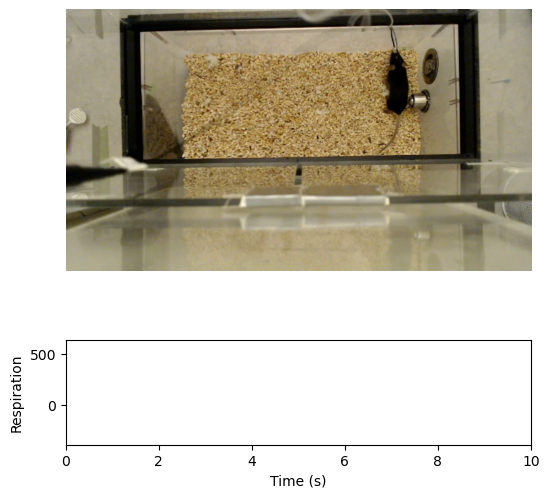

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---- Load video ----
cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# ---- Respiration ----
rsp, t = load_resp_simple(h5_file)

# ---- Figure layout ----
fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# First frame
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# Respiration plot
line, = ax_rsp.plot([], [], color="black", lw=1)
ax_rsp.set_ylim(np.percentile(rsp, 1), np.percentile(rsp, 99))
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

WINDOW = 10  # seconds shown in trace

def update(frame_idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current video time
    current_time = frame_idx / fps

    # Respiration up to now
    mask = t <= current_time

    line.set_data(t[mask], rsp[mask])
    ax_rsp.set_xlim(0, max(10, current_time))

    return im, line


ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)
ax_rsp.set_ylim(np.percentile(rsp, 1), np.percentile(rsp, 99))
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")


Saved respiration_with_video.mp4


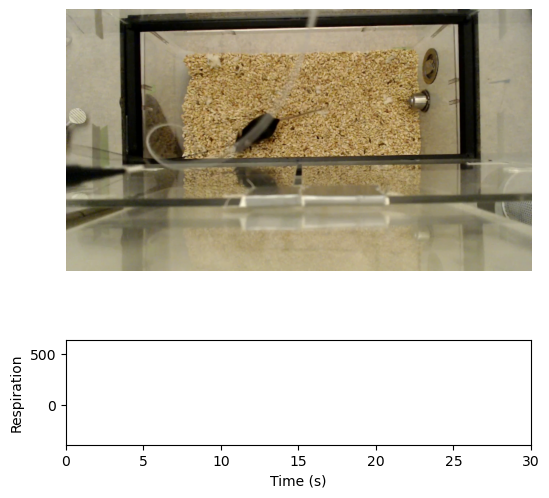

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

# ---------- Load video ----------
cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Render only first 30 seconds
MAX_SECONDS = 30
n_frames = int(MAX_SECONDS * fps)

# ---------- Load respiration ----------
rsp, t = load_resp_simple(h5_file)

# ---------- Figure ----------
fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# Read first frame ONCE
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# Resp axis
line, = ax_rsp.plot([], [], color="black", lw=1)
ax_rsp.set_ylim(np.percentile(rsp, 1), np.percentile(rsp, 99))
ax_rsp.set_xlim(0, MAX_SECONDS)
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# ---------- Update function ----------
def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time
    current_time = frame_idx / fps

    # Respiration up to now
    mask = t <= current_time
    line.set_data(t[mask], rsp[mask])

    return im, line

# ---------- Animation ----------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# ---------- Save ----------
writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    "respiration_with_video.mp4",
    writer=writer,
    dpi=120
)

print("Saved respiration_with_video.mp4")



In [ ]:
import os
print(os.getcwd())


c:\Users\sjs93\OneDrive\Documents\respiratory_pilot


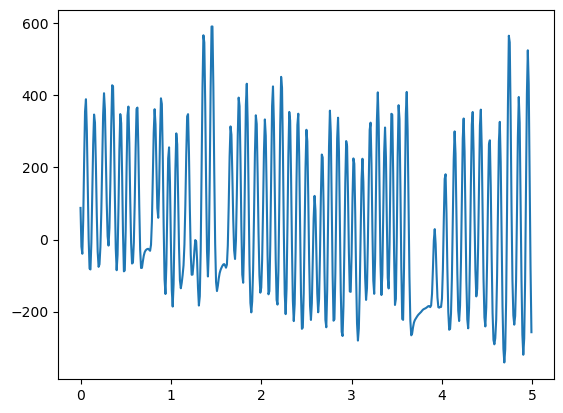

In [ ]:
plt.figure()
plt.plot(t[:500], rsp[:500])
plt.show()


Saved respiration_with_video.mp4


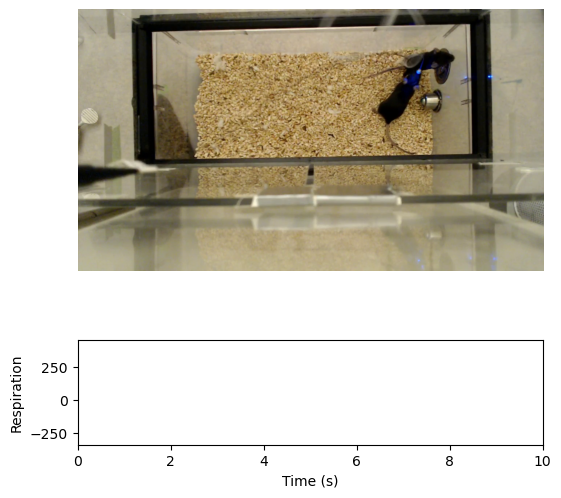

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

# ==============================
# Parameters (EDIT THESE)
# ==============================
START_TIME = 70.0      # seconds into recording
WINDOW_SEC = 10.0      # duration to display (seconds)
OUTFILE = "respiration_with_video.mp4"

# ==============================
# Load video
# ==============================
cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Jump to desired start time ONCE
start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

n_frames = int(WINDOW_SEC * fps)

# ==============================
# Load respiration
# ==============================
rsp, t = load_resp_simple(h5_file)

# Keep only respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the window we will display
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# ==============================
# Figure
# ==============================
fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- Video axis ---
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# --- Respiration axis ---
line, = ax_rsp.plot([], [], color="black", lw=1)
ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)
ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# ==============================
# Update function
# ==============================
def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video frame
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# ==============================
# Animation
# ==============================
ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# ==============================
# Save movie
# ==============================
writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"Saved {OUTFILE}")


Video FPS: 15.003987240829346
Starting at 70.0s (frame 1050)
Rendering 10.0s (150 frames)
Saved movie to: 1_1_RI1_f2_e_off_20260110_154830.1_resp_demo.mp4


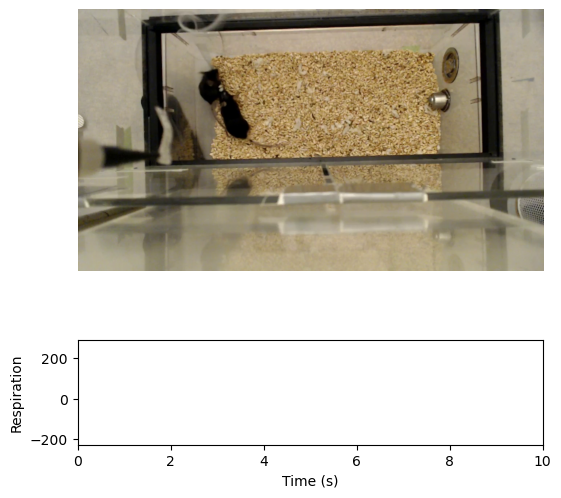

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import os

# =====================================================
# USER PARAMETERS — ONLY EDIT THESE
# =====================================================

# Path to MP4 (inside .rec folder)
mp4_path = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\1_1_RI1_f2_e_off_20260110_154830.rec\1_1_RI1_f2_e_off_20260110_154830.1.mp4"

# Path to matching H5 file
h5_file = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI1_hc_day2\h5_outputs\1_1_RI1_f2_e_off_20260110_154830.h5"

# When to start the clip (seconds into recording)
START_TIME = 70.0

# How much time to show (seconds)
WINDOW_SEC = 10.0

# Output movie name
OUTFILE = os.path.basename(mp4_path).replace(".mp4", "_resp_demo.mp4")

# =====================================================
# LOAD VIDEO
# =====================================================

cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Jump to start time ONCE (important for speed)
start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

# Number of frames to render
n_frames = int(WINDOW_SEC * fps)

print(f"Video FPS: {fps}")
print(f"Starting at {START_TIME}s (frame {start_frame})")
print(f"Rendering {WINDOW_SEC}s ({n_frames} frames)", flush=True)

# =====================================================
# LOAD RESPIRATION
# =====================================================

rsp, t = load_resp_simple(h5_file)

# Keep respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the window we will display
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# =====================================================
# SET UP FIGURE
# =====================================================

fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1,
    figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Video axis ----
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")

# ---- Respiration axis ----
line, = ax_rsp.plot([], [], color="black", lw=1)

ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)

ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# =====================================================
# UPDATE FUNCTION
# =====================================================

def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# =====================================================
# CREATE ANIMATION
# =====================================================

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# =====================================================
# SAVE MOVIE
# =====================================================

writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"Saved movie to: {OUTFILE}", flush=True)


In [ ]:
mp4_path = r"E:\Aim1\AIM1\Day1_new\RI1_s1_1_p5_2_nRB6_20250622_143958.rec\RI1_s1_1_p5_2_nRB6_20250622_143958.1.mp4"
h5_file = r"E:\Aim1\AIM1\Day1_new\h5_outputs\RI1_s1_1_p5_2_nRB6_20250622_143958.h5"


In [ ]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

[INFO] Cohort 1 (NO VIRUS)
[INFO] Video FPS: 13.001397999784922
[INFO] Starting at 10.0s (frame 130)
[INFO] Rendering 10.0s (130 frames)
[DONE] Saved movie to: RI1_s1_1_p5_2_nRB6_20250622_143958.1_resp_demo_cohort1.mp4


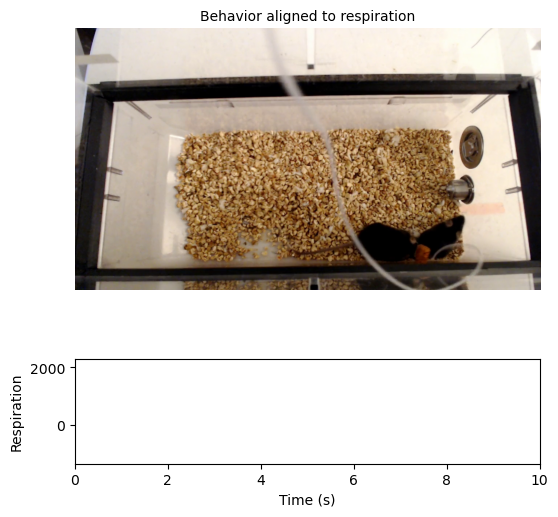

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import os

# =====================================================
# SESSION INFO (DOCUMENTATION ONLY)
# =====================================================
# Cohort: 1
# Virus: NONE
# Respiration source: merged H5, cleaned via load_clean_resp_signal
# Purpose: visualize respiration aligned to behavior video
# =====================================================

# =====================================================
# USER PARAMETERS — EDIT THESE ONLY
# =====================================================

# Path to MP4 (inside .rec folder)
mp4_path = r"E:\Aim1\AIM1\Day1_new\RI1_s1_1_p5_2_nRB6_20250622_143958.rec\RI1_s1_1_p5_2_nRB6_20250622_143958.1.mp4"

# Path to matching merged respiration H5
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"

# Start time for visualization (seconds into recording)
START_TIME = 10.0

# Duration to display (seconds)
WINDOW_SEC = 10.0

# Output movie name
OUTFILE = os.path.basename(mp4_path).replace(".mp4", "_resp_demo_cohort1.mp4")

# =====================================================
# LOAD VIDEO
# =====================================================

cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

n_frames = int(WINDOW_SEC * fps)

print("[INFO] Cohort 1 (NO VIRUS)")
print(f"[INFO] Video FPS: {fps}")
print(f"[INFO] Starting at {START_TIME}s (frame {start_frame})")
print(f"[INFO] Rendering {WINDOW_SEC}s ({n_frames} frames)", flush=True)

# =====================================================
# LOAD RESPIRATION (CLEANED + DOWNSAMPLED)
# =====================================================

rsp, t, fs = load_clean_resp_signal(h5_file)

# Keep respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the window to be displayed
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# =====================================================
# SET UP FIGURE
# =====================================================

fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1,
    figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Video axis ----
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")
ax_vid.set_title("Behavior aligned to respiration", fontsize=10)

# ---- Respiration axis ----
line, = ax_rsp.plot([], [], color="black", lw=1)

ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)

ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# =====================================================
# UPDATE FUNCTION
# =====================================================

def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video frame
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# =====================================================
# CREATE ANIMATION
# =====================================================

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# =====================================================
# SAVE MOVIE
# =====================================================

writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"[DONE] Saved movie to: {OUTFILE}", flush=True)


[INFO] Cohort 1 (NO VIRUS)
[INFO] Video FPS: 13.001397999784922
[INFO] Starting at 10.0s (frame 130)
[INFO] Rendering 10.0s (130 frames)
[DONE] Saved movie to: RI1_s1_1_p5_2_nRB6_20250622_143958.1_resp_demo_cohort1.mp4


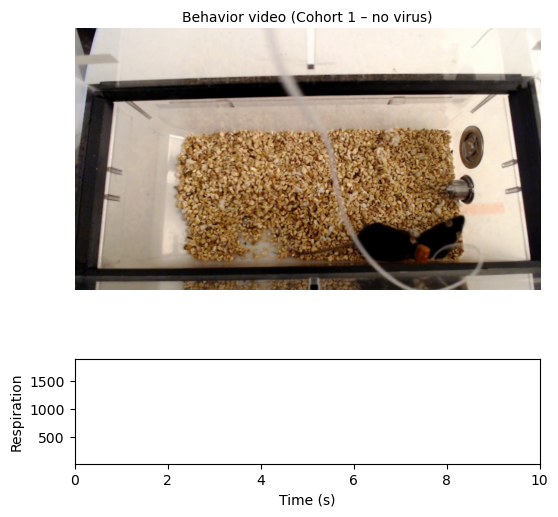

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
import os

# =====================================================
# SESSION INFO (DOCUMENTATION ONLY)
# =====================================================
# Cohort: 1
# Virus: NONE (no opsin, no control virus)
# Purpose: demo of respiration aligned to behavior video
# =====================================================

# =====================================================
# USER PARAMETERS — EDIT THESE ONLY
# =====================================================

# Path to MP4 (inside .rec folder)
mp4_path = r"E:\Aim1\AIM1\Day1_new\RI1_s1_1_p5_2_nRB6_20250622_143958.rec\RI1_s1_1_p5_2_nRB6_20250622_143958.1.mp4"

# Path to matching H5 file
h5_file = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"

# Start time for visualization (seconds into recording)
START_TIME = 10.0   # adjust if needed

# Duration to display (seconds)
WINDOW_SEC = 10.0

# Output movie name (auto-generated)
OUTFILE = os.path.basename(mp4_path).replace(".mp4", "_resp_demo_cohort1.mp4")

# =====================================================
# LOAD VIDEO
# =====================================================

cap = cv2.VideoCapture(mp4_path)
fps = cap.get(cv2.CAP_PROP_FPS)

start_frame = int(START_TIME * fps)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

n_frames = int(WINDOW_SEC * fps)

print(f"[INFO] Cohort 1 (NO VIRUS)")
print(f"[INFO] Video FPS: {fps}")
print(f"[INFO] Starting at {START_TIME}s (frame {start_frame})")
print(f"[INFO] Rendering {WINDOW_SEC}s ({n_frames} frames)", flush=True)

# =====================================================
# LOAD RESPIRATION
# =====================================================

rsp, t = load_resp_cohort1(h5_file)

# Keep respiration after START_TIME and re-zero time
mask_start = t >= START_TIME
rsp_seg = rsp[mask_start]
t_seg = t[mask_start] - START_TIME

# Keep only the display window
mask_win = t_seg <= WINDOW_SEC
rsp_seg = rsp_seg[mask_win]
t_seg = t_seg[mask_win]

# =====================================================
# SET UP FIGURE
# =====================================================

fig, (ax_vid, ax_rsp) = plt.subplots(
    2, 1,
    figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- Video axis ----
ret, frame = cap.read()
im = ax_vid.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax_vid.axis("off")
ax_vid.set_title("Behavior video (Cohort 1 – no virus)", fontsize=10)

# ---- Respiration axis ----
line, = ax_rsp.plot([], [], color="black", lw=1)

ax_rsp.set_xlim(0, WINDOW_SEC)
ax_rsp.set_ylim(
    np.percentile(rsp_seg, 1),
    np.percentile(rsp_seg, 99)
)

ax_rsp.set_xlabel("Time (s)")
ax_rsp.set_ylabel("Respiration")

# =====================================================
# UPDATE FUNCTION
# =====================================================

def update(frame_idx):
    ret, frame = cap.read()
    if not ret:
        return im, line

    # Update video frame
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Current time relative to START_TIME
    current_time = frame_idx / fps

    # Update respiration trace
    mask = t_seg <= current_time
    line.set_data(t_seg[mask], rsp_seg[mask])

    return im, line

# =====================================================
# CREATE ANIMATION
# =====================================================

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=1000 / fps,
    blit=False
)

# =====================================================
# SAVE MOVIE
# =====================================================

writer = FFMpegWriter(fps=fps, bitrate=1200)

ani.save(
    OUTFILE,
    writer=writer,
    dpi=120
)

print(f"[DONE] Saved movie to: {OUTFILE}", flush=True)


In [ ]:
import h5py
from IPython.display import display

with h5py.File(h5_file, "r") as f:
    display(list(f.keys()))



['ekg', 'ekg_metadata', 'metadata', 'resp', 'resp_metadata']